# Linear Regression - Predicting House Price

In [ ]:
pip install ucimlrepo

## Data Import

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets

In [2]:
# Check the type of X and y
type(X)

pandas.DataFrame

In [3]:
type(y)

pandas.DataFrame

In [4]:
# Sample the first 5 rows of X and y
X.head()  # Features/Predictors/Independent variables

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


In [5]:
y.head()  # Target/Response/Dependent variables

,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1


In [9]:
import pandas as pd

In [10]:
# Concatenation (joining) X and y.
house = pd.concat([X, y], axis=1)   # axis=1 join vertically (along columns)
house.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## Exploratory Data Analysis (EDA)

In [11]:
# Check for duplicate rows
house.duplicated().sum()

np.int64(0)

There is no duplicate records in the data.

In [12]:
# Check for null values
house.isnull().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

There is no null values in the data.

In [13]:
# Find outliers in each numeric column.
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
sns.boxplot?

Signature:
sns.boxplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    dodge='auto',
    width=0.8,
    gap=0,
    whis=1.5,
    linecolor='auto',
    linewidth=None,
    fliersize=None,
    hue_norm=None,
    native_scale=False,
    log_scale=None,
    formatter=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Draw a box plot to show distributions with respect to categories.

A box plot (or box-and-whisker plot) shows the distribution of quantitative
data in a way that facilitates comparisons between variables or across
levels of a categorical variable. The box shows the quartiles of the
dataset while the whiskers extend to show the rest of the distribution,
except for points that are determined to be "outliers" using a method
that is a function of the inter-quartile range.

See the :ref:`tutorial <categorical_tutorial>` for more i

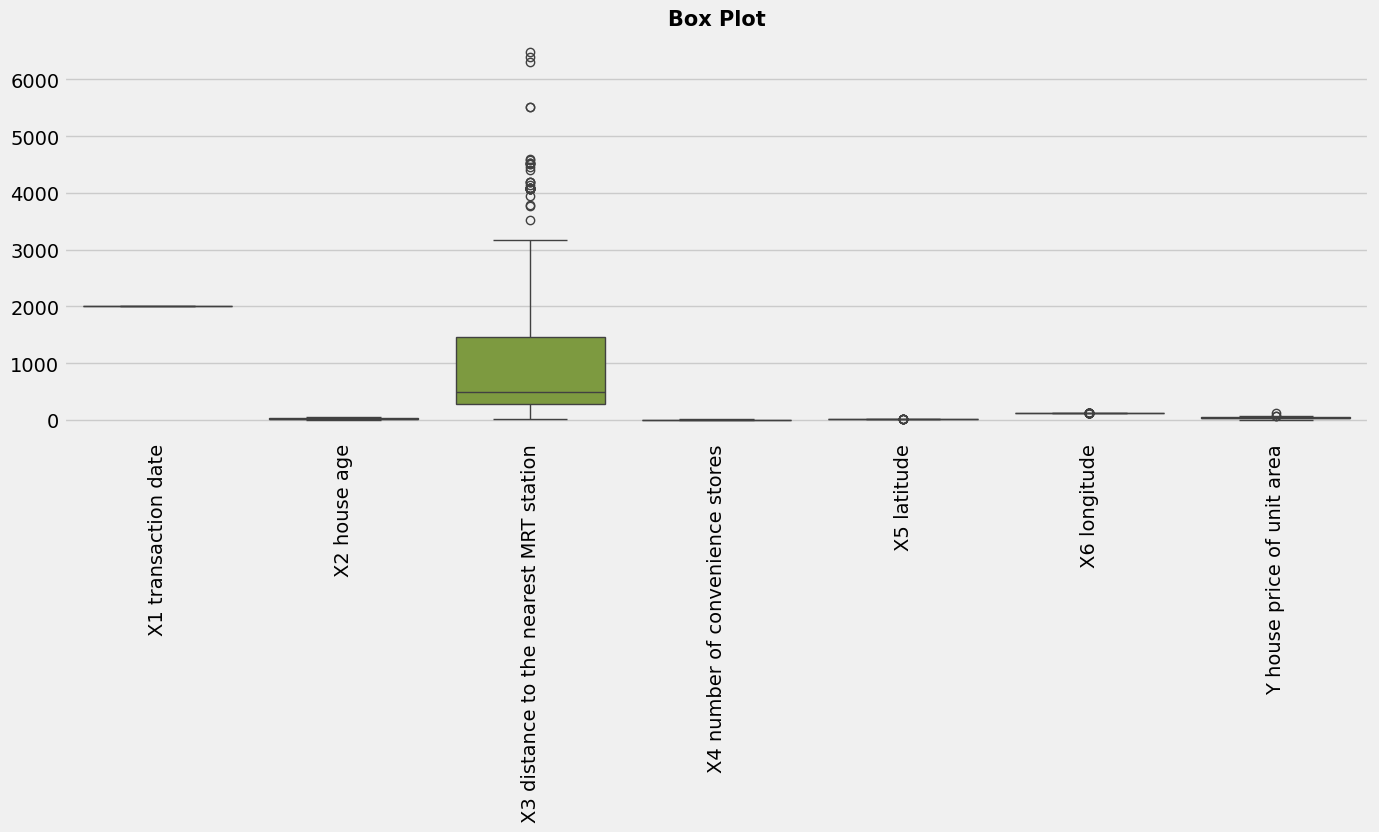

In [25]:
# If x and y parameters aren't specified, numeric columns in the data is automatically
# selected.
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15, 5))  # figsize=(width, height)
sns.boxplot(data=house)
plt.title('Box Plot', fontweight='bold', fontsize=15)  # Display title.
plt.xticks(rotation=90);  # Rotate x-ticks by 45 degrees.

In [26]:
house.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


Text(0, 0.5, 'House Price')

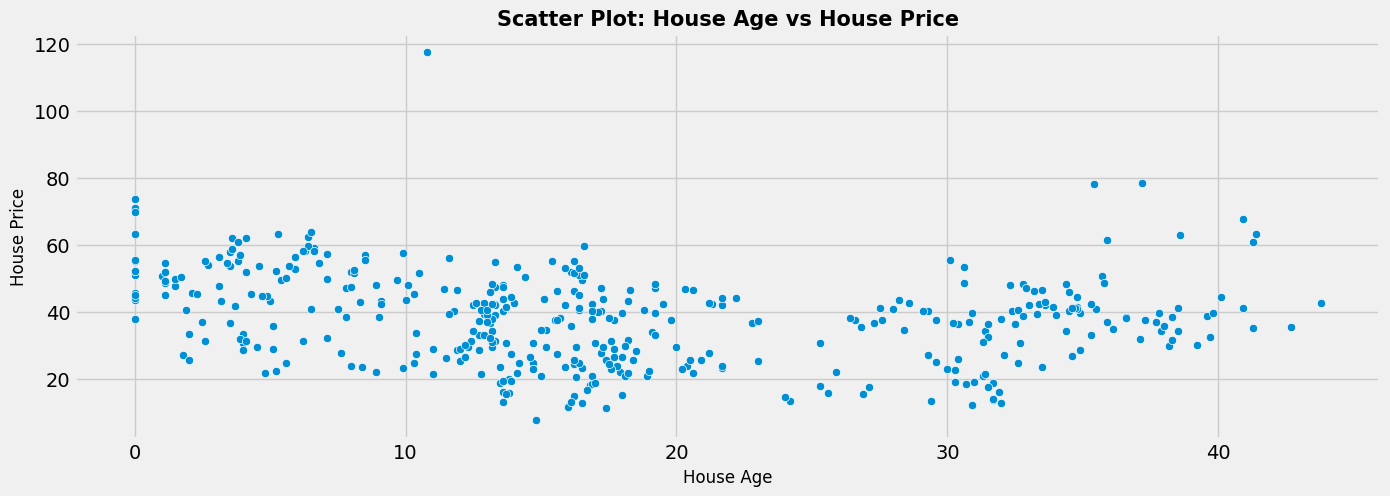

In [30]:
# Finding association between Age and House Price
plt.figure(figsize=(15, 5))
sns.scatterplot(data=house, 
                x='X2 house age',
                y='Y house price of unit area')
plt.title('Scatter Plot: House Age vs House Price', 
          fontweight='bold',
          fontsize=15)
plt.xlabel('House Age', fontsize=12)
plt.ylabel('House Price', fontsize=12)

Text(0, 0.5, 'House Price')

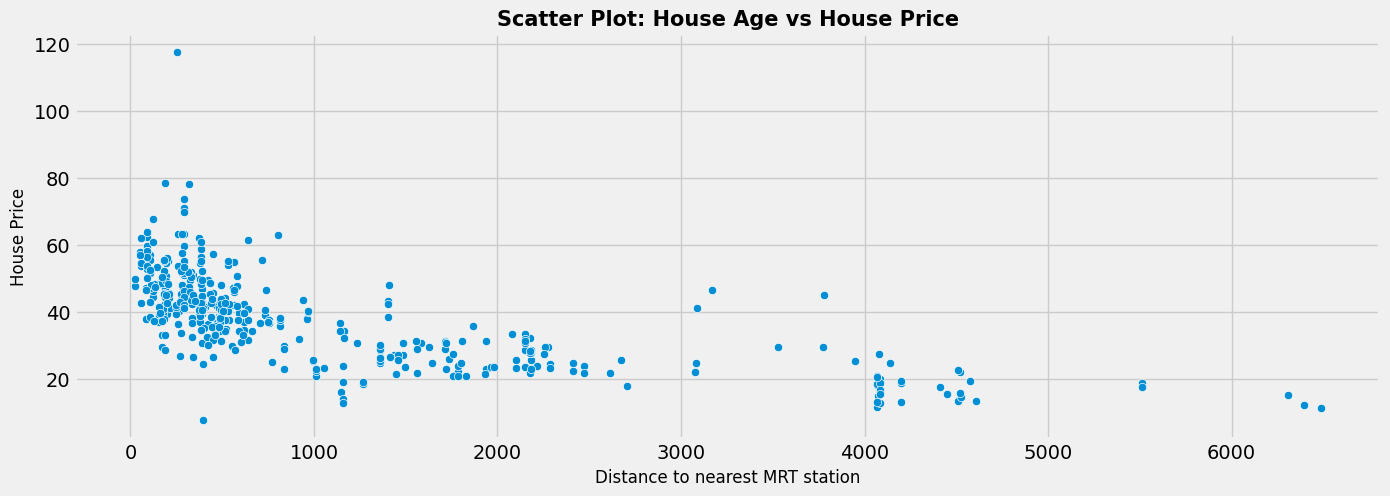

In [32]:
# Finding association between Distance to MRT station and House Price
plt.figure(figsize=(15, 5))
sns.scatterplot(data=house, 
                x='X3 distance to the nearest MRT station',
                y='Y house price of unit area')
plt.title('Scatter Plot: House Age vs House Price', 
          fontweight='bold',
          fontsize=15)
plt.xlabel('Distance to nearest MRT station', fontsize=12)
plt.ylabel('House Price', fontsize=12)

Text(0, 0.5, 'Longitude')

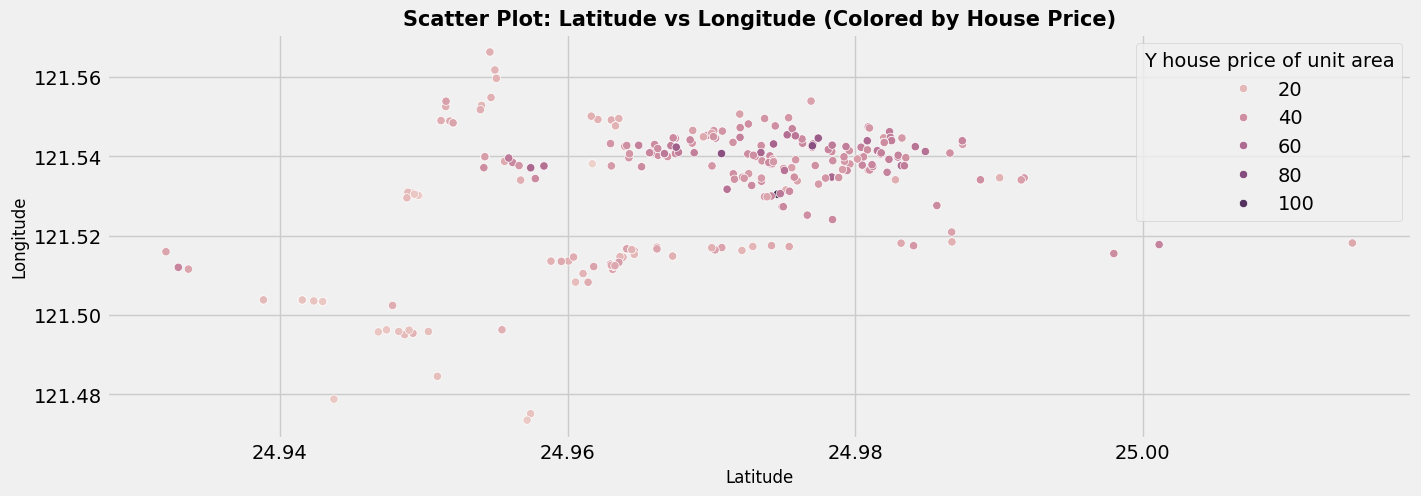

In [36]:
# Finding association between Location and House Price
# Finding association between Age and House Price
plt.figure(figsize=(15, 5))
sns.scatterplot(data=house, 
                x='X5 latitude',
                y='X6 longitude',
                hue='Y house price of unit area')
plt.title('Scatter Plot: Latitude vs Longitude (Colored by House Price)', 
          fontweight='bold',
          fontsize=15)
plt.xlabel('Latitude', fontsize=12)
plt.ylabel('Longitude', fontsize=12)

## Train-test Split

In [ ]:
pip install scikit-learn

In [37]:
from sklearn.model_selection import train_test_split

In [40]:
target_column = 'Y house price of unit area'

In [41]:
target = house[target_column]  # Extracts only the target column from house
predictive_features = ['X4 number of convenience stores',
                       'X3 distance to the nearest MRT station',
                       'X2 house age']
features = house[predictive_features]  # Select only `predictive_features` from house

In [42]:
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    target,
                                                    test_size=0.2)

## Model Training

We assume there's linear relationship between Age, Distance to Nearest MRT stations and Number of convenience stores. So, we're training a Linear Regression algorithm
to model the data.

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
linear_regression = LinearRegression()

In [45]:
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
linear_regression.coef_

array([ 1.30759303, -0.00514054, -0.26375094])

In [47]:
linear_regression.intercept_

np.float64(42.613012730672274)

## Model Evaluation

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [49]:
house_price_predictions = linear_regression.predict(X_test)

In [50]:
house_price_predictions[:5]

array([44.38890372, 32.83484921, 48.95240518, 32.65905906, 33.89850472])

In [51]:
y_test[:5]

44     53.9
15     50.5
105    71.0
10     41.4
76     36.8
Name: Y house price of unit area, dtype: float64

In [52]:
mae = mean_absolute_error(y_true=y_test, y_pred=house_price_predictions)
mse = mean_squared_error(y_true=y_test, y_pred=house_price_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_true=y_test, y_pred=house_price_predictions)

In [53]:
print('Test Performance')

print('Mean Absolute Error', mae)
print('Mean Squared Error', mse)
print('Root Mean Squared Error', rmse)
print('R2 Score', r2)

Test Performance
Mean Absolute Error 6.73624459507436
Mean Squared Error 81.01532231714958
Root Mean Squared Error 9.00085119958938
R2 Score 0.5967742234093996


In [ ]:
Equation: 42.6 + 1.30 * X1 - 0.05 * X2 - 0.26 * X3